# Diferencia en Diferencias ($Diff-in-Differences$): Aprovechando los Datos de Panel

¡Bienvenido a uno de los pilares más robustos de la inferencia causal! Hasta ahora, nos hemos centrado principalmente en datos de **corte transversal** ($cross-sectional$), que son como una "fotografía" instantánea de diferentes unidades en un momento dado. En este capítulo, daremos el salto a los **datos de panel**, que funcionan más como un "video": observamos a las mismas unidades repetidamente a lo largo del tiempo.

### ¿Por qué son tan potentes los datos de panel?

Imagina que quieres medir el impacto de una campaña de marketing offline. Si solo comparas ciudades con campaña frente a ciudades sin ella, te enfrentarás al problema de los **confundidores no observados**. Quizás las ciudades que eligieron la campaña son inherentemente más innovadoras o tienen una infraestructura diferente que no puedes medir.

El "superpoder" de los datos de panel es que nos permiten controlar por características que son **invariantes en el tiempo**, incluso si no las vemos. Si un factor (como la cultura de una ciudad) no cambia entre el "antes" y el "después", podemos eliminar su efecto simplemente restando los estados de la unidad en diferentes tiempos.

### Los Regímenes de Datos

1.  **Corte Transversal ($Cross-sectional$):** Cada unidad aparece una sola vez.
2.  **Corte Transversal Repetido:** Diferentes unidades en diferentes periodos (ej. una encuesta anual a personas distintas).
3.  **Datos de Panel ($Longitudinal$):** Las mismas unidades seguidas a través del tiempo. Es el estándar de oro para observar trayectorias individuales.

### La Intuición de Diferencia en Diferencias ($DiD$)

El estimador de $DiD$ busca responder: *¿Cuál fue el cambio en el grupo de tratamiento por encima del cambio en el grupo de control?*

Matemáticamente, lo expresamos como:

$$
\delta_{DiD} = (E[Y_{post} | T=1] - E[Y_{pre} | T=1]) - (E[Y_{post} | T=0] - E[Y_{pre} | T=0])
$$

Donde:
*   $T=1$ es el grupo que recibe el tratamiento.
*   $T=0$ es el grupo de control.
*   $pre$ y $post$ indican los periodos antes y después de la intervención.

En esencia, la primera resta $(E[Y_{post} | T=1] - E[Y_{pre} | T=1])$ captura el cambio total en el grupo tratado, pero este cambio incluye tanto el efecto del tratamiento como el paso del tiempo. La segunda resta captura la tendencia natural del tiempo en el grupo de control. Al restarlas, aislamos el **efecto causal neto**.

In [1]:
import polars as pl
import numpy as np

mkt_data = (
    pl.read_csv("../data/short_offline_mkt_south.csv")
    .with_columns(
        pl.col("date").str.to_datetime()
    )
)

mkt_data.head()

date,city,region,treated,tau,downloads,post
datetime[μs],i64,str,i64,f64,f64,i64
2021-05-01 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-02 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-03 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-04 00:00:00,5,"""S""",0,0.0,50.0,0
2021-05-05 00:00:00,5,"""S""",0,0.0,49.0,0


Primero se hizo el calculo del ATE de manera promediada, luego el efecto pro individuo, ahora el analizis de unidades a lo largo del tiempo.

In [2]:
(
    mkt_data
    .with_columns(
        w = pl.col("treated") * pl.col("post")
    )
    .group_by("w")
    .agg(
        pl.col("date").min().alias("date_min"),
        pl.col("date").max().alias("date_max"),
    )
)


w,date_min,date_max
i64,datetime[μs],datetime[μs]
0,2021-05-01 00:00:00,2021-06-01 00:00:00
1,2021-05-15 00:00:00,2021-06-01 00:00:00


La métrica que buscas estimar es el **Efecto Promedio del Tratamiento sobre los Tratados** (**ATT**, por sus siglas en inglés: *Average Treatment effect on the Treated*). Formalmente, el ATT responde a la pregunta:

> *¿Cuál es el efecto causal promedio de la campaña de marketing offline en las ciudades que realmente recibieron el tratamiento, después de que este ocurre?*

En notación matemática, el ATT se expresa como:

$$
ATT = E\left[ Y_{it}(1) - Y_{it}(0) \mid D_i = 1,\, t > T_{pre} \right]
$$

Donde:

- $Y_{it}(1)$: Descargas (o resultado de interés) para la ciudad $i$ en el tiempo $t$ **si** recibe el tratamiento.
- $Y_{it}(0)$: Descargas para la ciudad $i$ en el tiempo $t$ **si no** recibe el tratamiento.
- $D_i = 1$: La ciudad $i$ pertenece al grupo tratado.
- $t > T_{pre}$: Observaciones **después** del inicio de la campaña.

**Intuición:**  
El ATT compara, para las ciudades tratadas, el resultado observado tras la campaña con el resultado *contrafactual* (lo que habría pasado sin la campaña), promediando sobre todas las ciudades tratadas y periodos post-tratamiento.



![Captura de pantalla 2026-01-15 115038.png](<attachment:Captura de pantalla 2026-01-15 115038.png>)
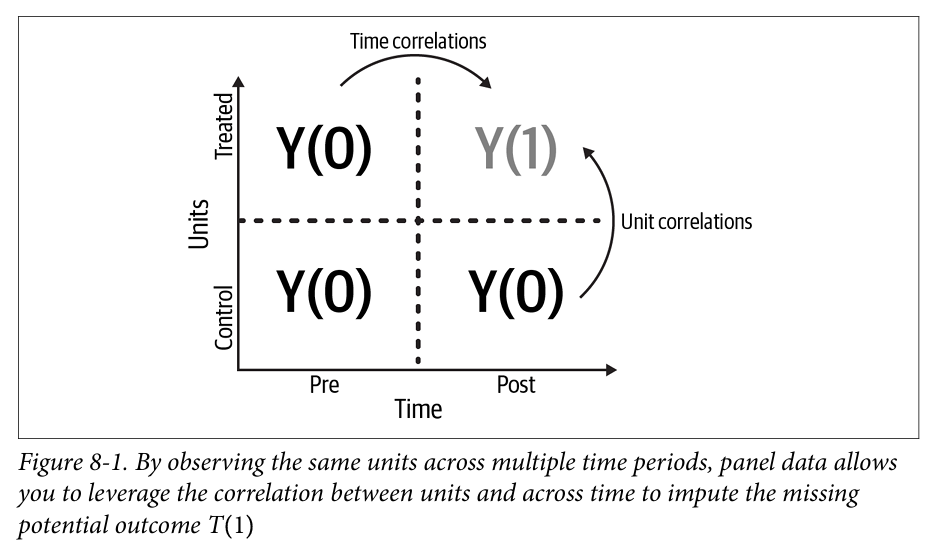

## Canonical Difference-in-Differences

In [3]:
did_data = (
    mkt_data
    .group_by(["treated", "post"])
    .agg(
        pl.col("downloads").mean().alias("mean_downloads"),
        pl.col("date").min().alias("date_min"),
    )
)
did_data

treated,post,mean_downloads,date_min
i64,i64,f64,datetime[μs]
1,0,50.944444,2021-05-01 00:00:00
1,1,51.858025,2021-05-15 00:00:00
0,1,50.556878,2021-05-15 00:00:00
0,0,50.335034,2021-05-01 00:00:00


In [4]:
wide = (
    did_data
    .pivot(
        values="mean_downloads",
        index="treated",
        on="post",
        aggregate_function="first",
    )
)

t_pre  = wide.filter(pl.col("treated") == 1).select(pl.col("0")).item()
t_post = wide.filter(pl.col("treated") == 1).select(pl.col("1")).item()
c_pre  = wide.filter(pl.col("treated") == 0).select(pl.col("0")).item()
c_post = wide.filter(pl.col("treated") == 0).select(pl.col("1")).item()

att = t_post - t_pre - (c_post - c_pre)

print(f"El ATT estimado es: {att:.6f} descargas promedio por ciudad tratada.")


El ATT estimado es: 0.691736 descargas promedio por ciudad tratada.


In [5]:
wide

treated,0,1
i64,f64,f64
1,50.944444,51.858025
0,50.335034,50.556878


In [6]:

mkt_data.filter((pl.col("post") == 1) & (pl.col("treated") == 1)).select(pl.col("tau").mean()).item()

0.7660316402518459

### Diff-in-Diff with Outcome Growth

In [7]:
pre = mkt_data.filter(pl.col("post") == 0).group_by("city").agg(
    pl.col("downloads").mean().alias("mean_pre")
)
post = mkt_data.filter(pl.col("post") == 1).group_by("city").agg(
    pl.col("downloads").mean().alias("mean_post")
)

delta_y = pre.join(post, on="city").with_columns(
    (pl.col("mean_post") - pl.col("mean_pre")).alias("delta_y")
).join(
    mkt_data.group_by("city").agg(pl.col("treated").max()),
    on="city"
).sort("city")

delta_y

city,mean_pre,mean_post,delta_y,treated
i64,f64,f64,f64,i64
5,50.642857,50.166667,-0.47619,0
15,49.142857,49.166667,0.02381,0
20,48.785714,49.055556,0.269841,0
22,50.142857,50.166667,0.02381,0
28,49.571429,49.944444,0.373016,0
…,…,…,…,…
192,48.5,49.055556,0.555556,0
193,50.5,50.666667,0.166667,0
195,53.357143,53.777778,0.420635,0


In [8]:
(
    delta_y
    .filter(pl.col("treated") == 1)
    .select(pl.col("delta_y")
    .mean())
    .item() 
    -
    delta_y
    .filter(pl.col("treated") == 0)
    .select(pl.col("delta_y").mean())
    .item()
 )
 

0.6917359536407155

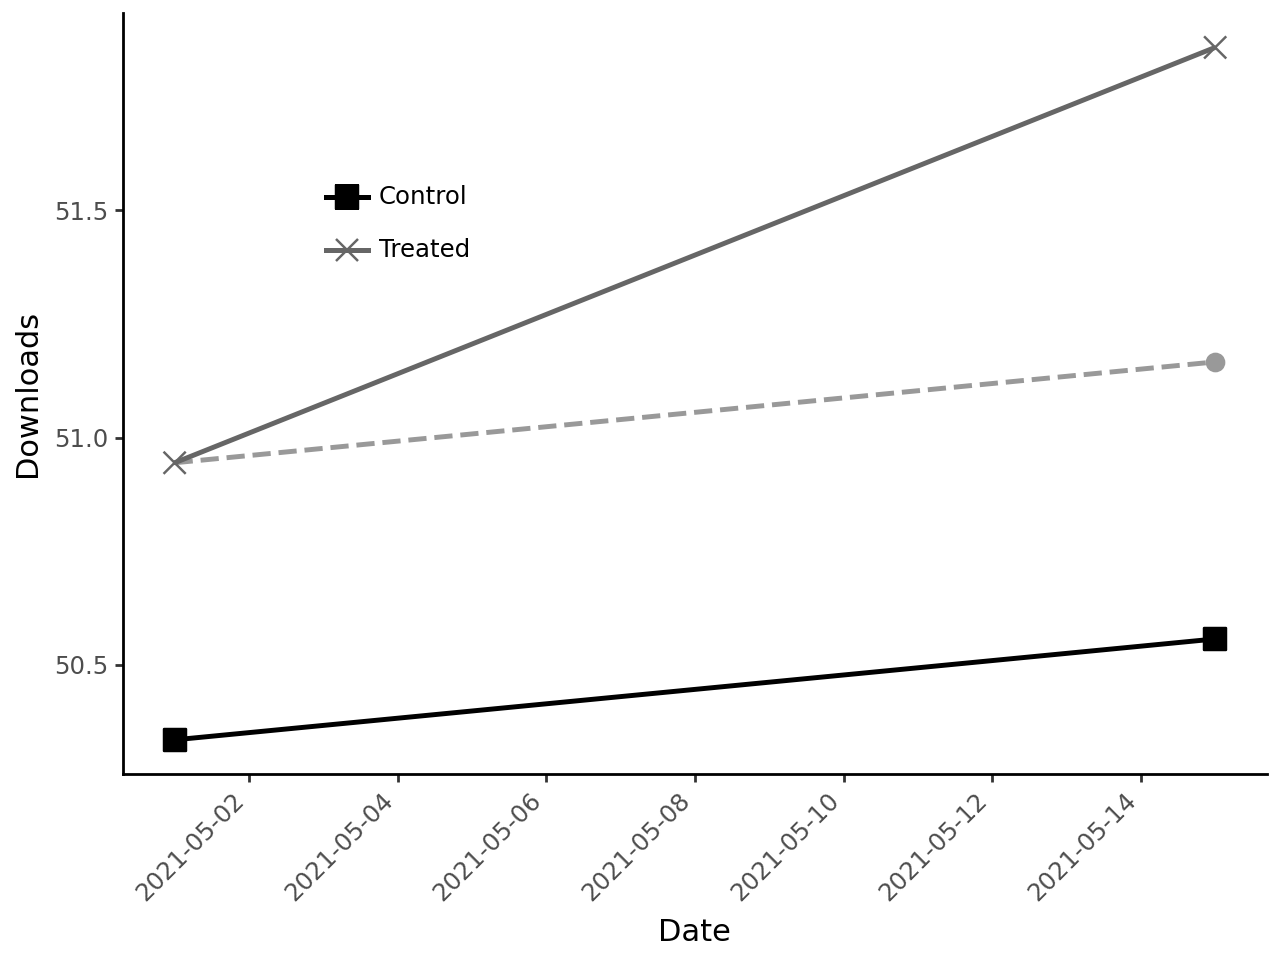

In [9]:
from plotnine import *

# Filtramos los valores observados
c_pre = did_data.filter((pl.col("treated") == 0) & (pl.col("post") == 0))["mean_downloads"].item()
c_post = did_data.filter((pl.col("treated") == 0) & (pl.col("post") == 1))["mean_downloads"].item()
t_pre = did_data.filter((pl.col("treated") == 1) & (pl.col("post") == 0))["mean_downloads"].item()

# Fechas para el eje X (tomamos la primera coincidencia de cada periodo)
date_pre = did_data.filter(pl.col("post") == 0)["date_min"].head(1).item()
date_post = did_data.filter(pl.col("post") == 1)["date_min"].head(1).item()

# Cálculo del Contrafactual (Tendencias Paralelas)
# Pendiente del Control + Inicio del Tratamiento
y0_est = t_pre + (c_post - c_pre)

# --- 2. Construcción de DataFrames para el Plot (100% Polars) ---

# A) DataFrame para la línea contrafactual (Dashed line)Ñ
cf_data = pl.DataFrame({
    "date_min": [date_pre, date_post],
    "mean_downloads": [t_pre, y0_est],
    "type": ["Counterfactual", "Counterfactual"]
})

# B) DataFrame principal con etiquetas legibles
# Usamos pl.when().then() para crear la columna categórica de etiquetas
main_data = did_data.with_columns(
    pl.when(pl.col("treated") == 1)
    .then(pl.lit("Treated"))
    .otherwise(pl.lit("Control"))
    .alias("type")
)

# --- 3. Visualización con Plotnine ---
# Plotnine acepta DataFrames de Polars directamente en versiones recientes

(
    ggplot()
    # CAPA 1: Línea Contrafactual (Gris punteada)
    + geom_line(data=cf_data, mapping=aes(x="date_min", y="mean_downloads"),
                linetype="dashed", color="#999999", size=1)
    + geom_point(data=cf_data.tail(1), mapping=aes(x="date_min", y="mean_downloads"),
                 color="#999999", size=3, shape="o") # Punto hueco/gris al final
    
    # CAPA 2: Datos Observados
    + geom_line(data=main_data, mapping=aes(x="date_min", y="mean_downloads", group="type", color="type"), size=1)
    + geom_point(data=main_data, mapping=aes(x="date_min", y="mean_downloads", color="type", shape="type"), size=4)
    
    # Estilos Manuales (Replicando la imagen)
    + scale_color_manual(values={"Control": "black", "Treated": "#666666"}) 
    + scale_shape_manual(values={"Control": "s", "Treated": "x"}) 
    
    # Formato
    + labs(x="Date", y="Downloads", color="", shape="") # Quitamos títulos de leyenda
    + theme_classic()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        legend_position=(0.2, 0.8), # Ajusta coordenadas (x,y) según tus datos 0-1
        legend_background=element_rect(fill="white", alpha=0) # Fondo transparente
    )
)

## Diff-in-Diff With OLS

In [10]:
did_data = (
    mkt_data
    .group_by(["city", "post"])
    .agg(
        pl.col("downloads").mean().alias("downloads"),
        pl.col("date").min().alias("date_min"),
        pl.col("treated").max().alias("treated"),
    )
).sort("city", descending=False)
did_data

city,post,downloads,date_min,treated
i64,i64,f64,datetime[μs],i64
5,0,50.642857,2021-05-01 00:00:00,0
5,1,50.166667,2021-05-15 00:00:00,0
15,1,49.166667,2021-05-15 00:00:00,0
15,0,49.142857,2021-05-01 00:00:00,0
20,1,49.055556,2021-05-15 00:00:00,0
…,…,…,…,…
195,1,53.777778,2021-05-15 00:00:00,0
196,1,52.333333,2021-05-15 00:00:00,0
196,0,52.214286,2021-05-01 00:00:00,0


In [11]:
import statsmodels.formula.api as smf

smf.ols(
    formula="downloads ~ treated*post",
    data=did_data.to_pandas()
).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,50.3350,0.252,199.760,0.000,49.835,50.835
treated,0.6094,0.600,1.016,0.312,-0.581,1.800
post,0.2218,0.356,0.623,0.535,-0.485,0.929
treated:post,0.6917,0.848,0.815,0.417,-0.992,2.375


## Diff-in-Diff with Fixed Effects



In [12]:
smf.ols(
    formula="downloads ~ C(city) + C(post) + treated*post",
    data=mkt_data.to_pandas()
).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,50.2502,0.177,283.643,0.000,49.903,50.598
C(city)[T.15],-1.2188,0.247,-4.938,0.000,-1.703,-0.735
C(city)[T.20],-1.4375,0.247,-5.825,0.000,-1.922,-0.953
C(city)[T.22],-0.2187,0.247,-0.886,0.376,-0.703,0.265
C(city)[T.28],-0.5937,0.247,-2.406,0.016,-1.078,-0.110
C(city)[T.29],1.7500,0.247,7.091,0.000,1.266,2.234
C(city)[T.30],2.7673,0.166,16.700,0.000,2.442,3.092
C(city)[T.31],-0.0625,0.247,-0.253,0.800,-0.547,0.422
C(city)[T.36],1.7500,0.247,7.091,0.000,1.266,2.234
C(city)[T.39],1.5937,0.247,6.458,0.000,1.110,2.078


## Multiple Time Periods 

In [13]:
import polars as pl
from plotnine import *

# 1. Preparar datos para el Heatmap
# Queremos que cada ciudad tenga un valor de "sort_val" basado en su estado final
heat_data = (
    mkt_data
    .with_columns([
        pl.col("date").dt.strftime("%Y-%m-%d").alias("date_str"),
        (pl.col("treated") * pl.col("post")).alias("is_treated")
    ])
    .with_columns(
        # Buscamos el valor de is_treated solo para la última fecha, por ciudad
        sort_val = pl.col("is_treated")
                   .filter(pl.col("date") == pl.col("date").max())
                   .max() # Tomamos el valor (0 o 1)
                   .over("city") # Lo expandimos a todas las filas de esa ciudad
    )
)

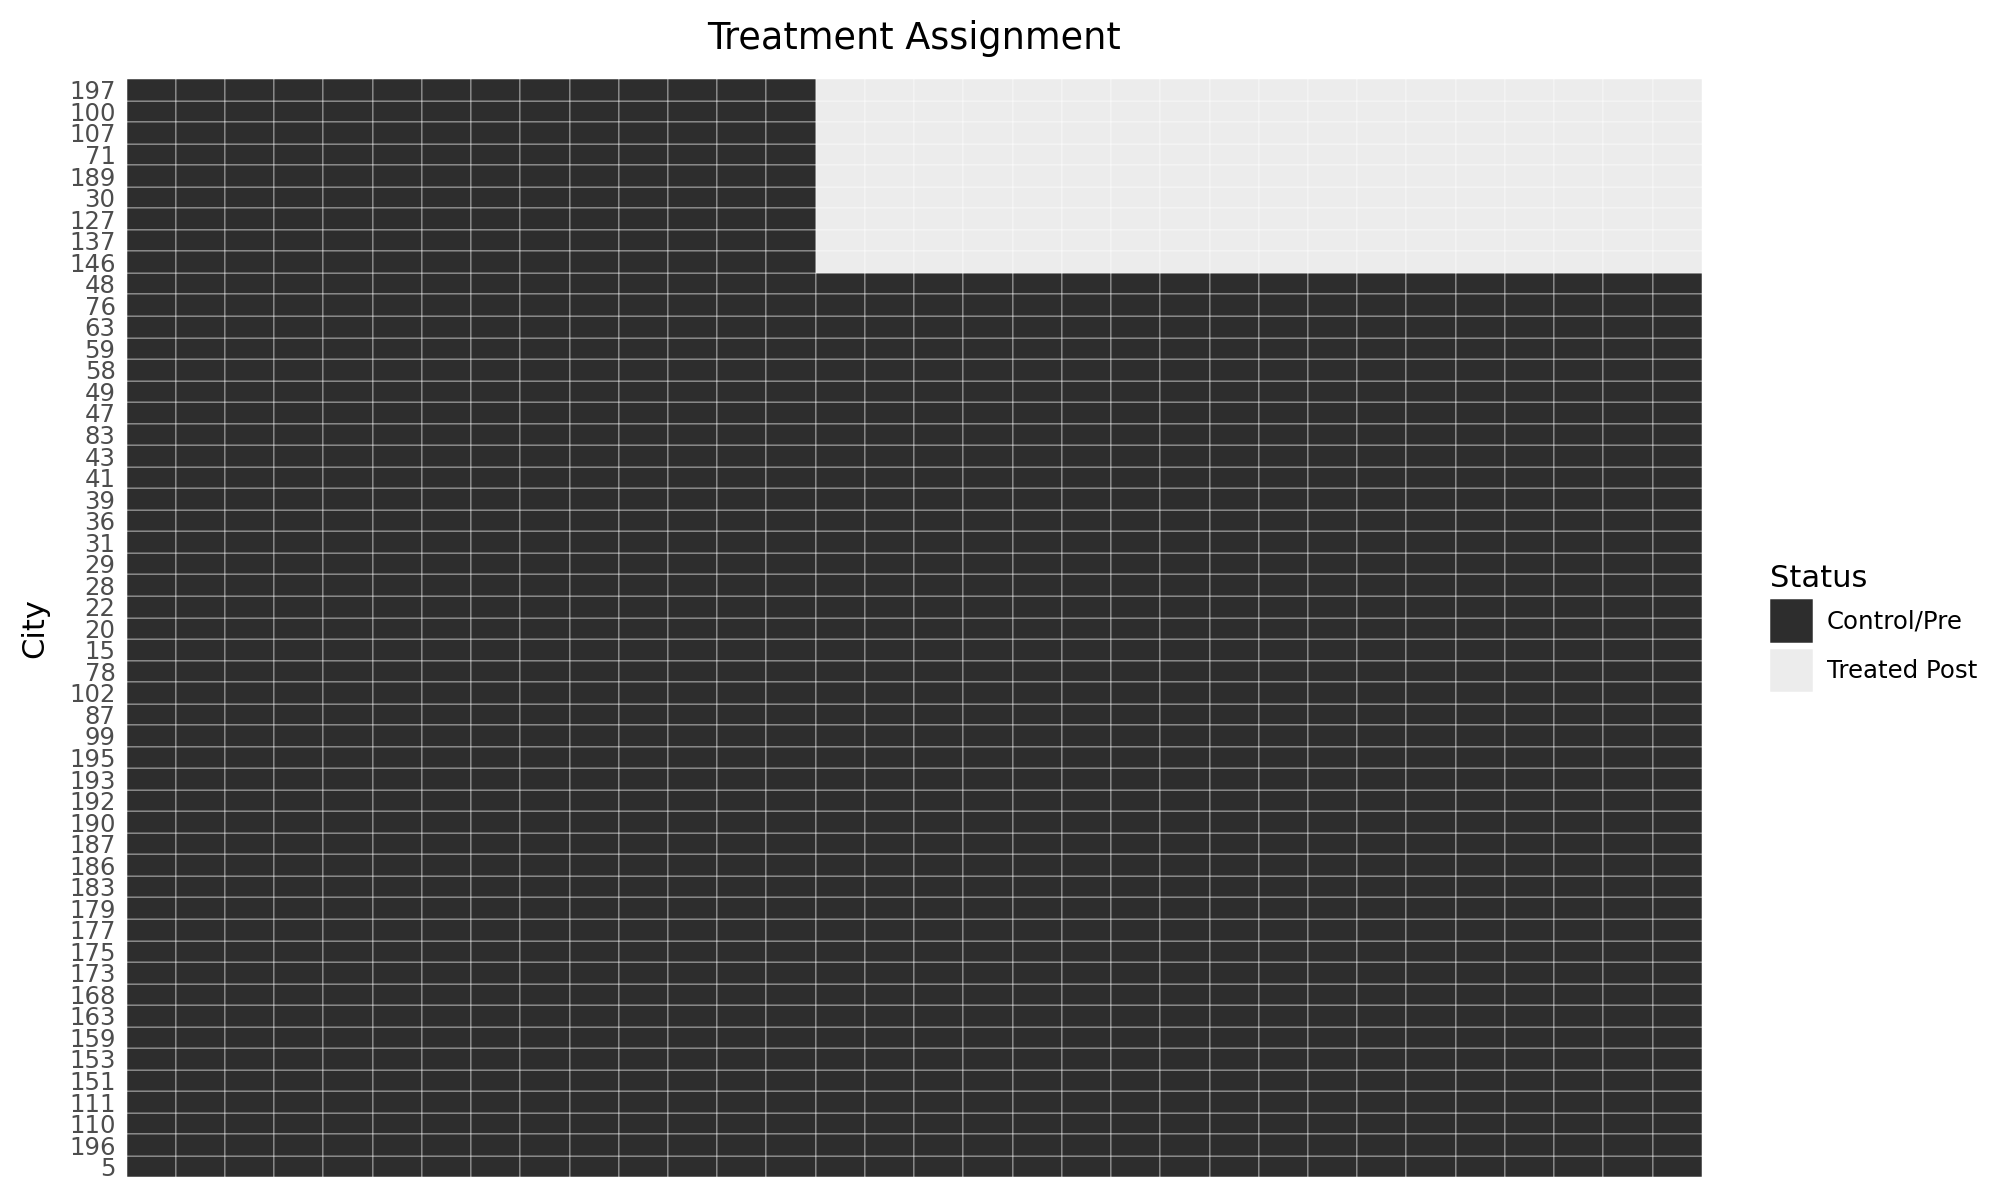

In [14]:
(
    ggplot(heat_data, aes(x="date_str", y="reorder(city, sort_val)", fill="factor(is_treated)"))
    + geom_tile(color="white", size=0.1) # Líneas blancas para separar celdas
    + scale_fill_manual(values=["#2d2d2d", "#ececec"], labels=["Control/Pre", "Treated Post"])
    + labs(title="Treatment Assignment", x="", y="City", fill="Status")
    + theme_minimal()
    + theme(
        axis_text_x=element_blank(),
        axis_ticks_x=element_blank(),
        figure_size=(10, 6),
        panel_grid=element_blank()
    )
)

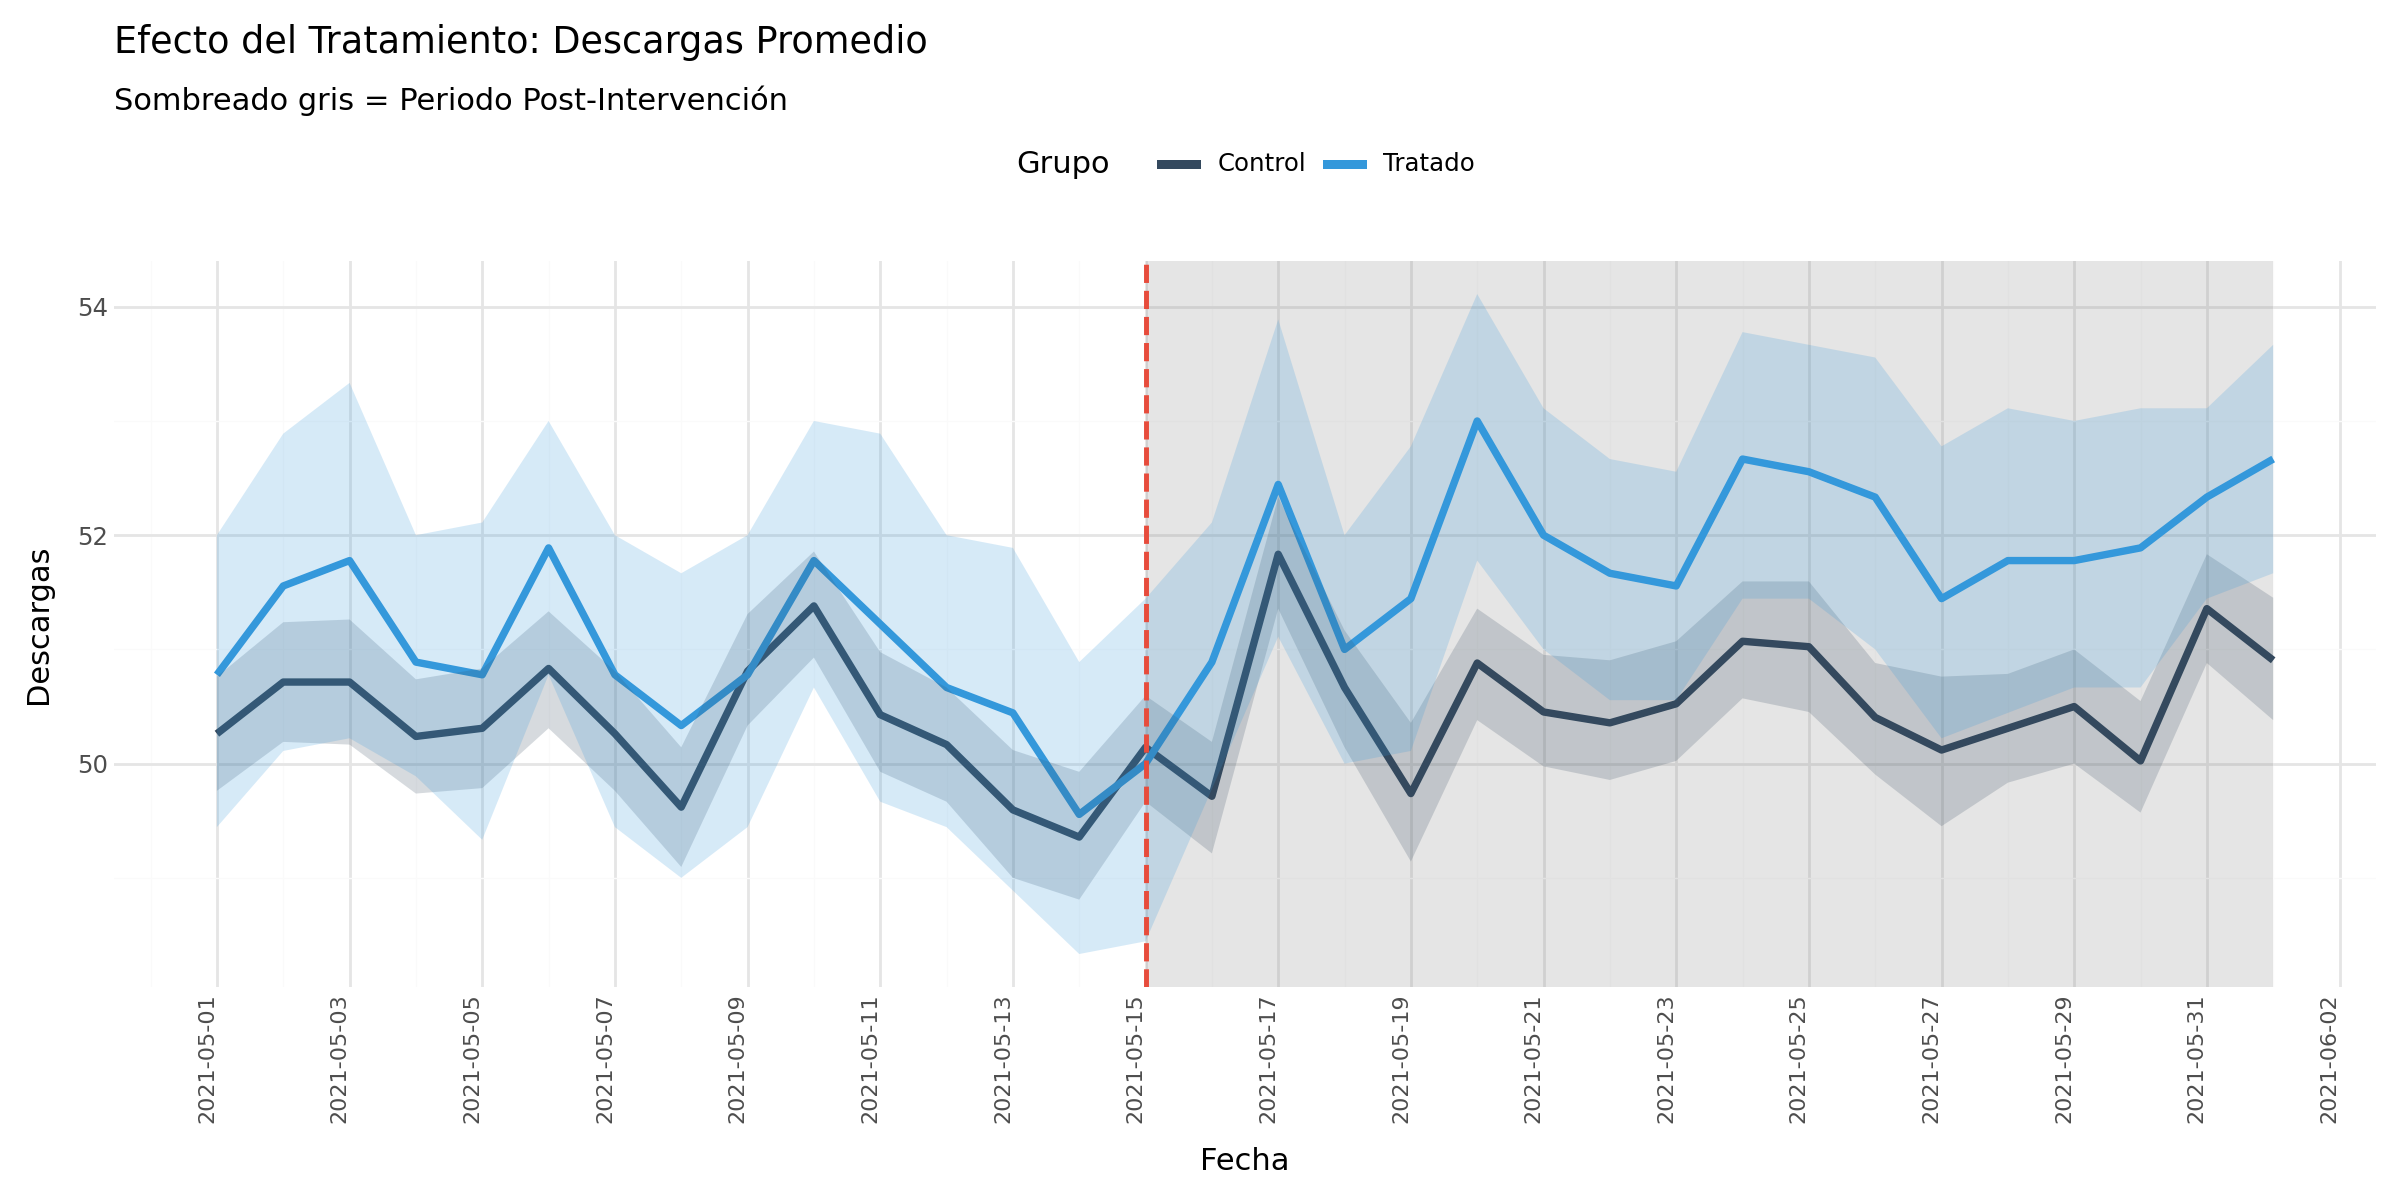

In [15]:
import polars as pl
import numpy as np
from plotnine import *
from datetime import date

# 1. Obtener las fechas como objetos de fecha reales, no strings
# La fecha de intervención es el 15 de mayo de 2021
fecha_intervencion_dt = date(2021, 5, 15)
# La última fecha la sacamos directamente de la columna de fechas original
fecha_final_dt = heat_data["date"].max()

(
    # --- CAMBIO CLAVE: Usamos x="date" en lugar de "date_str" ---
    ggplot(heat_data, aes(x="date", y="downloads", group="treated"))
    
    # 2. ANNOTATE: Usamos los objetos de fecha para los límites
    + annotate("rect", 
               xmin=fecha_intervencion_dt, 
               xmax=fecha_final_dt, 
               ymin=-np.inf, 
               ymax=np.inf, 
               fill="gray", 
               alpha=0.2)
    
    # 3. Líneas y Ribbons (igual que antes)
    + stat_summary(aes(color="factor(treated)"), fun_y=np.mean, geom="line", size=1.5)
    + stat_summary(aes(fill="factor(treated)"), fun_data="mean_cl_boot", geom="ribbon", alpha=0.2)
    
    # 4. Línea vertical: Usamos el objeto de fecha
    + geom_vline(xintercept=fecha_intervencion_dt, linetype="dashed", color="#e74c3c", size=1)
    
    # 5. Estética, Etiquetas y Formato de Fecha
    + scale_color_manual(values=["#34495e", "#3498db"], labels=["Control", "Tratado"])
    + scale_fill_manual(values=["#34495e", "#3498db"], guide=None)
    
    # --- NUEVO: Formateamos el eje X para que se vea bien ---
    + scale_x_date(date_labels="%Y-%m-%d", date_breaks="2 days")
    
    + labs(
        title="Efecto del Tratamiento: Descargas Promedio",
        subtitle="Sombreado gris = Periodo Post-Intervención",
        x="Fecha",
        y="Descargas",
        color="Grupo"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=90, hjust=1, size=8),
        figure_size=(12, 6),
        legend_position="top"
    )
)



## Inference

In [16]:
m = smf.ols(
    formula="downloads ~ C(city) + C(date) + treated:post",
    data=mkt_data.to_pandas()
).fit(cov_kwds={'groups': mkt_data['city'].to_pandas()}, cov_type='cluster')

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407196


0    0.296101
1    1.087370
Name: treated:post, dtype: float64

In [17]:
m = smf.ols(
    formula="downloads ~ treated:post + C(city) + C(date)",
    data=mkt_data.to_pandas()
).fit()
print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407196


0    0.478014
1    0.905457
Name: treated:post, dtype: float64

In [18]:
m = smf.ols(
    formula="downloads ~ C(city) + C(date_min) + treated:post",
    data=did_data.to_pandas()
).fit(cov_kwds={'groups': did_data['city'].to_pandas()}, cov_type='cluster')

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407346


0    0.138188
1    1.245284
Name: treated:post, dtype: float64

**Comparación de Estrategias de Inferencia en Diff-in-Diff**

| Estrategia                          | Intervalo de Confianza         | Riesgo Principal                        |
|--------------------------------------|-------------------------------|-----------------------------------------|
| **Regresión Diaria sin Clúster**     | Muy estrecho                  | Falso optimismo (subestima la incertidumbre) |
| **Regresión Agregada con Clúster**   | Muy ancho                     | Exceso de cautela (puedes perder efectos reales) |
| **Regresión Diaria con Clúster**     | Balanceado y honesto          | Aprovecha la información temporal sin subestimar la incertidumbre |

**Conclusión:**  
La regresión diaria con errores estándar agrupados (clúster) es el enfoque más recomendable: utiliza toda la variabilidad temporal y ajusta correctamente la incertidumbre, evitando tanto el falso optimismo como la excesiva cautela.

In [19]:
def block_sample(df, unit_col):
    # Si el DataFrame tiene el método to_pandas, lo convertimos a pandas para facilitar el muestreo
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True)

    return (df
            .set_index(unit_col)
            .loc[sample]
            .reset_index(level=[unit_col])
            )

from joblib import Parallel, delayed

def block_bootstrap(data, est_fn, unit_col,
                    rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)

    stats = Parallel(n_jobs=-1)(
        delayed(est_fn)(block_sample(data, unit_col))
        for _ in range(rounds)
    )

    return np.percentile(stats, pcts)

In [21]:
def est_fn(df):
    m = smf.ols(
        formula="downloads ~ C(city) + C(date) + treated:post",
        data=df
    ).fit()
    return m.params["treated:post"]

block_bootstrap(mkt_data, est_fn, unit_col="city")

array([0.23162214, 1.14002646])

## Identification Assumptions

#### Paralell Trends

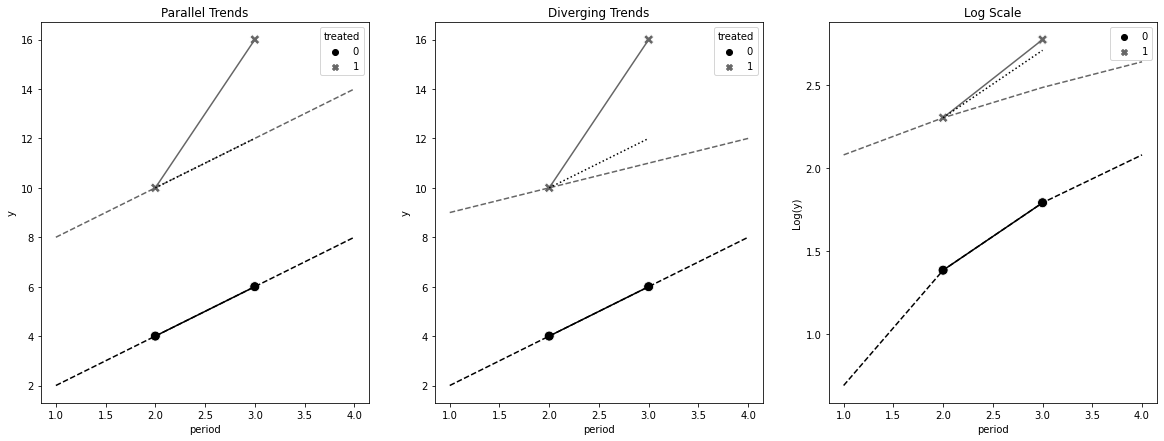

$$ATT = \underbrace{(E[Y | D=1, Post=1] - E[Y | D=1, Post=0])}_{\text{Cambio en el Tratado}} - \underbrace{(E[Y | D=0, Post=1] - E[Y | D=0, Post=0])}_{\text{Cambio en el Control}}$$

$$
Y_{it} = \beta_0 + \beta_1 D_i + \beta_2 Post_t + \beta_3 (D_i \times Post_t) + \epsilon_{it}
$$

**¿Qué significa cada coeficiente?**

- $\beta_0$: El nivel base del grupo de control antes del tratamiento.
- $\beta_1$: La diferencia inicial (sesgo) entre tratado y control antes de empezar.
- $\beta_2$: La tendencia o crecimiento natural del mercado a través del tiempo.
- $\beta_3$: Este es el DiD (ATT). Es el efecto adicional que ocurre solo cuando se es del grupo tratado **y** se está en el periodo post.

## No Anticipation Assumption and SUTVA

SUTVA se refiere a la "Stable Unit Treatment Value Assumption" (Suposición de Valor Estable del Tratamiento para las Unidades). Esta suposición tiene dos componentes clave:

1. **No Interferencia entre Unidades:** El tratamiento aplicado a una unidad no afecta el resultado de otra unidad. Por ejemplo, si una ciudad recibe una campaña de marketing, esto no debería influir en las descargas de aplicaciones en otra ciudad que no recibió la campaña.

2. **Supuesto de no anticipación:** Las unidades no anticipan el tratamiento antes de que ocurra. Es decir, el comportamiento de las unidades no cambia antes de la implementación del tratamiento debido a expectativas sobre el mismo.

## Strict Exogenity

### Resumen Matemático

El modelo de efectos fijos se expresa así:

$$
Y_{it} = \alpha_{i} + \beta W_{it} + \epsilon_{it}
$$

Donde:

- $Y_{it}$: Resultado observado (por ejemplo, descargas) para la ciudad $i$ en el momento $t$.
- $\alpha_{i}$: Efecto fijo de la ciudad. Captura todas las variables invariantes en el tiempo (cultura, leyes, población).
- $W_{it}$: Variable de tratamiento (1 si hay oferta, 0 si no).
- $\beta$: El efecto causal que queremos estimar.
- $\epsilon_{it}$: Error o residuo, que debe cumplir la **Exogeneidad Estricta**:  
    $$
    E[\epsilon_{it} \mid W, \alpha] = 0
    $$

---

### Pequeño Ejemplo

Imagina que comparas las descargas de combustible en Ciudad A (metrópolis con mucho tráfico) y Ciudad B (pueblo pequeño).

- **Problema:** Si solo comparas descargas, Ciudad A siempre tendrá más por su tamaño de población, no por tus ofertas.
- **Solución (Efectos Fijos):** El modelo asigna un "punto de partida" ($\alpha_{i}$) para cada ciudad.  
    - Para Ciudad A será alto (ej. 1000), para Ciudad B bajo (ej. 100).

**Violación del Supuesto (Efecto de Arrastre):**  
Si lanzas una oferta el lunes y genera descargas el martes, pero el modelo no tiene una variable de "oferta" para el martes, ese aumento se va al error ($\epsilon_{it}$).  
Como ese error ahora "sabe" que hubo una oferta el lunes, se rompe la independencia matemática y tu cálculo de $\beta$ será sesgado.

---

### Visualización con el DAG

En el diagrama causal, la **Ciudad** (nodo rojo) actúa como un escudo que bloquea la influencia de la cultura o leyes sobre el resultado, dejando el camino libre para observar solo el efecto de $W$ (Tratamiento) sobre $Y$ (Resultado) en cada tiempo $T$.

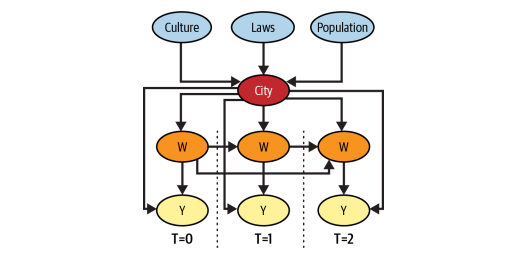